> # SECTION -2

--- 
- ***Visualize quantum circuits***

- Visualize quantum measurements

- Visualize quantum states
---

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ## Visualize quantum circuits

REFERENCE : https://quantum.cloud.ibm.com/docs/en/guides/visualize-circuits

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.h(1)
qc.measure(0, 0)

### Draw a circuit 
- draw method
- print the circuit object

In [3]:
print("Without using the output parameter will get the format as text drawer")
qc.draw()

Without using the output parameter will get the format as text drawer


┌───┐┌─┐
q_0: ┤ X ├┤M├
     ├───┤└╥┘
q_1: ┤ H ├─╫─
     └───┘ ║ 
c: 2/══════╩═
           0

In [4]:
print(qc)

     ┌───┐┌─┐
q_0: ┤ X ├┤M├
     ├───┤└╥┘
q_1: ┤ H ├─╫─
     └───┘ ║ 
c: 2/══════╩═
           0 


### output rendering there are different formats:
1. text
2. matplotllib
3. latex
4. latex_source

In [5]:
print(" use text as output style")
qc.draw(output="text")

 use text as output style


┌───┐┌─┐
q_0: ┤ X ├┤M├
     ├───┤└╥┘
q_1: ┤ H ├─╫─
     └───┘ ║ 
c: 2/══════╩═
           0

### mpl
returns: matplotlib.Figure object

use matplotlib


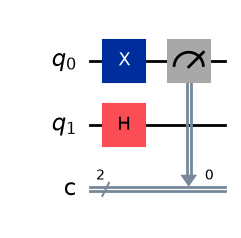

In [6]:
print("use matplotlib")
qc.draw(output="mpl")

### Latex
Required to install

It returns the PIL.image as an object

PIL.image(output='latex')

### NOTE: For latex, a separate package required 

## ADVANCED options 

> barriers :
- Non-unitary operation
- Better visualization

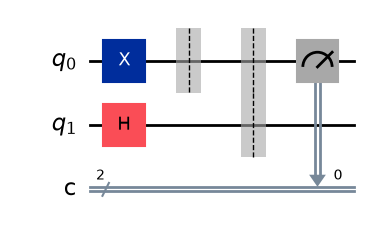

In [7]:
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.barrier(0)
qc.h(1)
qc.barrier()
qc.measure(0, 0)

qc.draw(output="mpl")

> barriers:Enable/disable drawing barriers in the output circuit

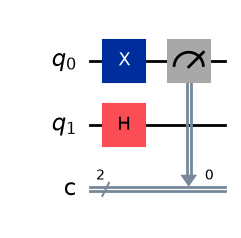

In [8]:
qc.draw(output="mpl",
       
        plot_barriers=False, # hide barriers
        
)

> initial_state=True

Shows
- ∣0⟩ in the beginning of the qubit wires and 

- 0 to classical wires

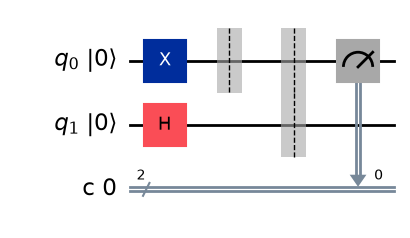

In [9]:
qc.draw(output="mpl",
        initial_state=True,
      )

On a circuit diagram, By default, 0 at the top

-- qubit 0 is the topmost qubit, and 

-- qubit n−1 the bottommost qubit

> reverse_bits : reverse the bit order inside registers for the output visualization

 qubit n-1 is at the top


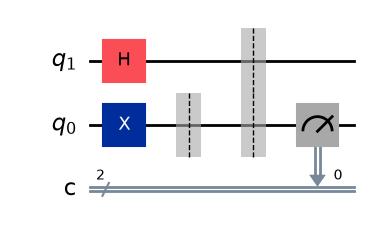

In [10]:
print(" qubit n-1 is at the top")
qc.draw(output="mpl",
        reverse_bits=True,       
)

> # Render-specific

> style, background 

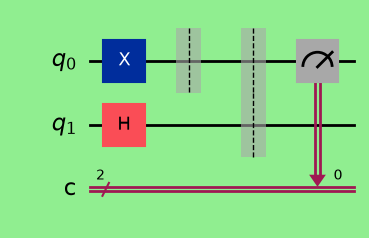

In [11]:
style = {
    "backgroundcolor": "lightgreen","creglinecolor":"#9F1853",
}

qc.draw(
    output="mpl",
    style=style,
    
)

> Style : uses only black white display

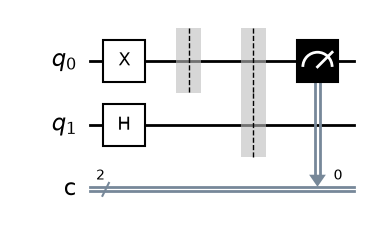

In [12]:
qc.draw(
    output="mpl",
    style="bw"
)

> other options for style

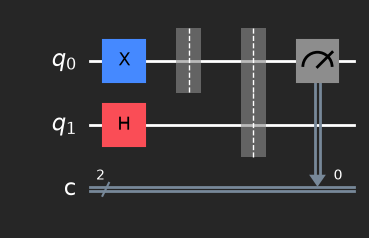

In [13]:
qc.draw(
    output="mpl",
    style="iqp-dark"
)

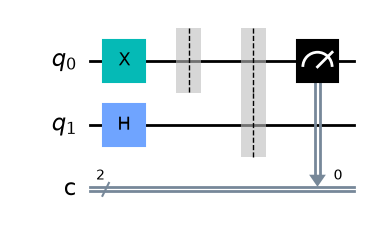

In [14]:
qc.draw(
    output="mpl",
    style="clifford"
)

> Saving the output file 

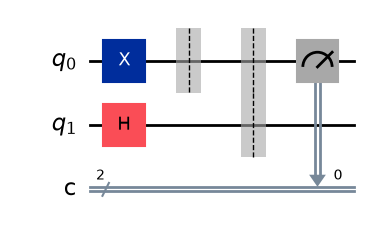

In [15]:
qc.draw(
    output="mpl",filename="Fig_mpl.jpg"
)

> # CIRCUIT visualization: 

circuit draw method: self-contained function ,circuit_drawer() function ,alternative way , 

-- circuit object as a required argument

-- same functionality

REFERENCE: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.circuit_drawer

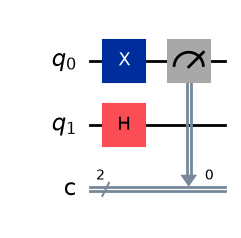

In [16]:
from qiskit.visualization import circuit_drawer

circuit_drawer(qc, output="mpl", plot_barriers=False)

> # more complex circuits

> fold : fold argument sets a maximum width for the output.

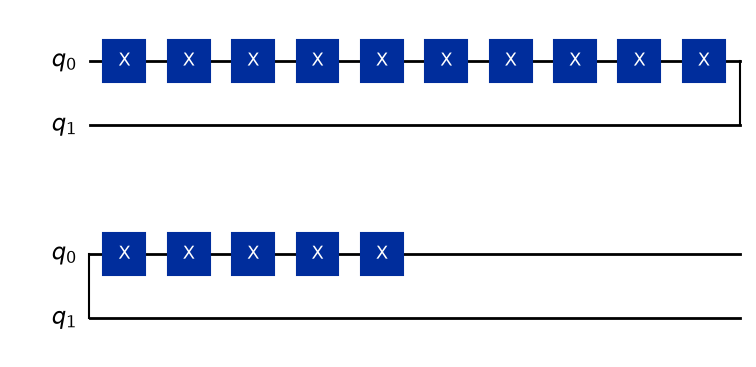

In [17]:
qc = QuantumCircuit(2)
for i in range(15):
    qc.x(0)

qc.draw(output="mpl",fold=10)


> text renderer: sets the length of the lines of the diagram before it is wrapped to the next line

In [18]:
qc.draw(output="text",fold=40)

┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
q_0: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
     └───┘└───┘└───┘└───┘└───┘└───┘»
q_1: ──────────────────────────────»
                                   »
«     ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«q_0: ┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├»
«     └───┘└───┘└───┘└───┘└───┘└───┘»
«q_1: ──────────────────────────────»
«                                   »
«     ┌───┐┌───┐┌───┐
«q_0: ┤ X ├┤ X ├┤ X ├
«     └───┘└───┘└───┘
«q_1: ───────────────
«

In [19]:
qc.draw(output="text",fold=30)

┌───┐┌───┐┌───┐┌───┐»
q_0: ┤ X ├┤ X ├┤ X ├┤ X ├»
     └───┘└───┘└───┘└───┘»
q_1: ────────────────────»
                         »
«     ┌───┐┌───┐┌───┐┌───┐»
«q_0: ┤ X ├┤ X ├┤ X ├┤ X ├»
«     └───┘└───┘└───┘└───┘»
«q_1: ────────────────────»
«                         »
«     ┌───┐┌───┐┌───┐┌───┐»
«q_0: ┤ X ├┤ X ├┤ X ├┤ X ├»
«     └───┘└───┘└───┘└───┘»
«q_1: ────────────────────»
«                         »
«     ┌───┐┌───┐┌───┐
«q_0: ┤ X ├┤ X ├┤ X ├
«     └───┘└───┘└───┘
«q_1: ───────────────
«

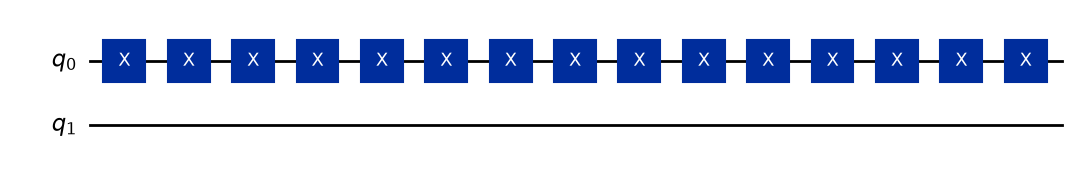

In [20]:
qc.draw(output="mpl")

> scale :Scale of image to draw (shrink if < 1.0).

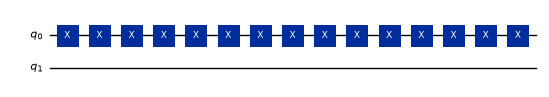

In [21]:
qc.draw(output="mpl",scale=0.5)